# 03 Exploratory Data Analysis

Use this notebook to explore trends, distributions, segments, anomalies, and early business signals.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/clean_retail_data.csv")

In [2]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    12575 non-null  str    
 1   customer_id       12575 non-null  str    
 2   category          12575 non-null  str    
 3   item              12575 non-null  str    
 4   price_per_unit    12575 non-null  float64
 5   quantity          12575 non-null  int64  
 6   total_spent       12575 non-null  float64
 7   payment_method    12575 non-null  str    
 8   location          12575 non-null  str    
 9   transaction_date  12575 non-null  str    
 10  discount_applied  12575 non-null  bool   
 11  month             12575 non-null  int64  
 12  day               12575 non-null  str    
 13  year              12575 non-null  int64  
dtypes: bool(1), float64(2), int64(3), str(8)
memory usage: 1.3 MB


,price_per_unit,quantity,total_spent,month,year
count,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000
mean,23.369304,5.318489,124.555626,6.366441,2023.042386
std,10.748728,2.952320,95.221135,3.503156,0.855581
min,5.000000,1.000000,5.000000,1.000000,2022.000000
25%,14.000000,3.000000,43.500000,3.000000,2022.000000
50%,23.000000,5.000000,100.000000,6.000000,2023.000000
75%,33.500000,8.000000,184.000000,9.000000,2024.000000
max,41.000000,10.000000,410.000000,12.000000,2025.000000


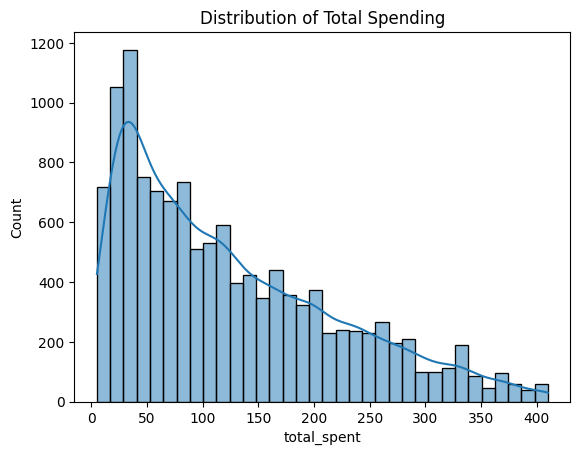

In [3]:
# UNIVARIATE ANALYSIS
sns.histplot(df["total_spent"], kde=True)
plt.title("Distribution of Total Spending")
plt.show()


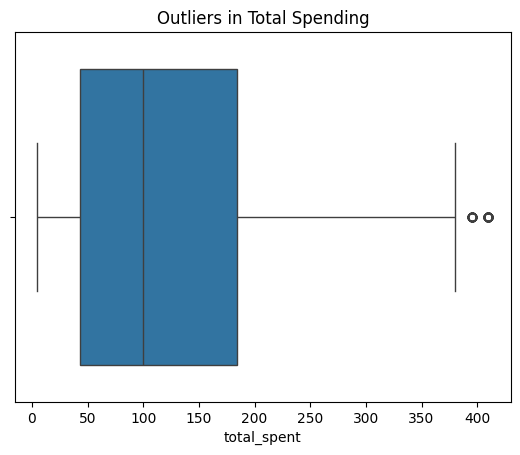

In [4]:
sns.boxplot(x=df["total_spent"])
plt.title("Outliers in Total Spending")
plt.show()

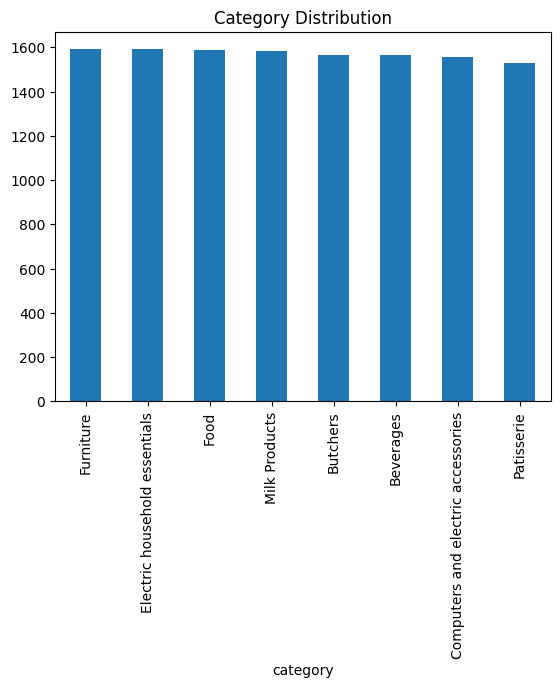

In [5]:
df["category"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.show()

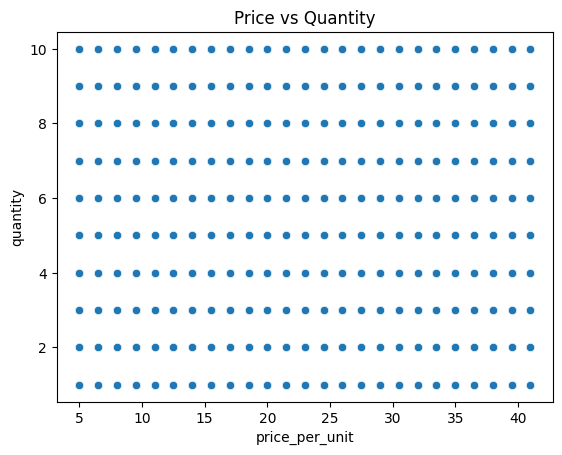

In [6]:
# BIVARIATE ANALYSIS
# Price vs Quantity
sns.scatterplot(x="price_per_unit", y="quantity", data=df)
plt.title("Price vs Quantity")
plt.show()

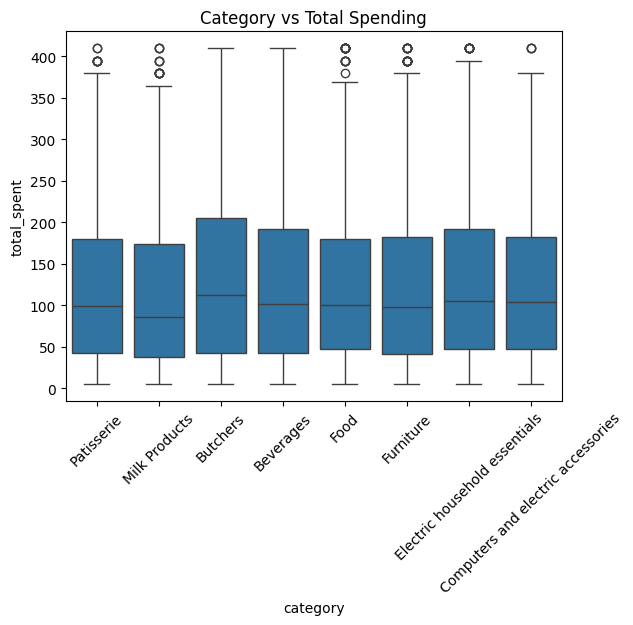

In [7]:
# Category vs Spending
sns.boxplot(x="category", y="total_spent", data=df)
plt.xticks(rotation=45)
plt.title("Category vs Total Spending")
plt.show()

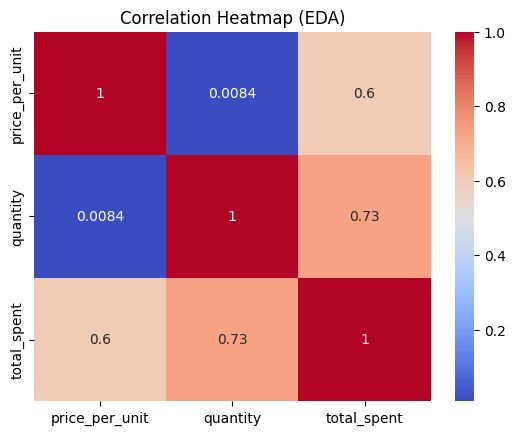

In [8]:
# Correlation
corr = df[["price_per_unit", "quantity", "total_spent"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (EDA)")
plt.show()

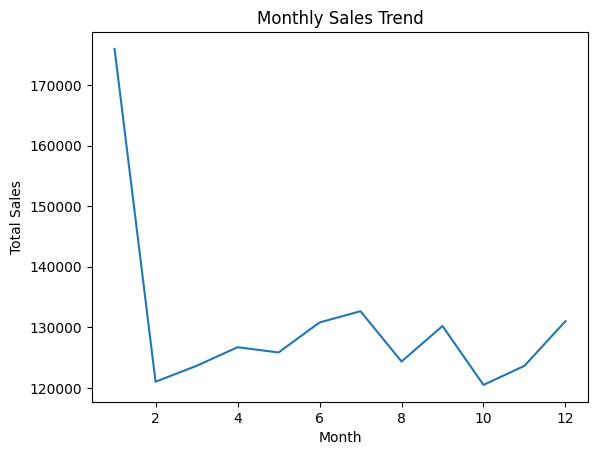

In [9]:
# Time-Based Trends
sales_trend = df.groupby("month")["total_spent"].sum()

sales_trend.plot(kind="line", title="Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

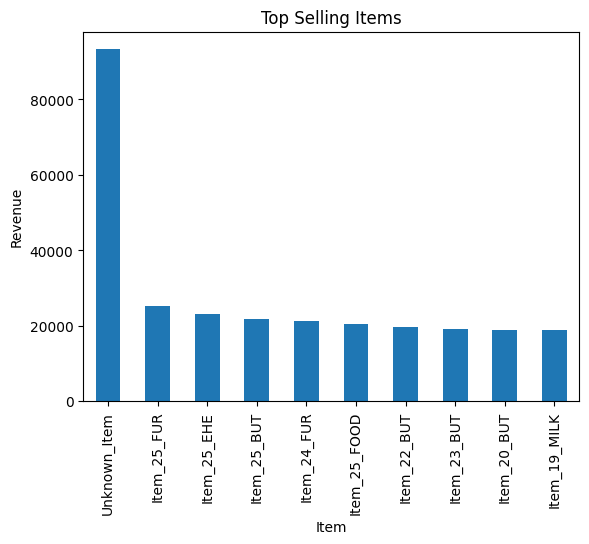

In [10]:
# Top Products
top_items = df.groupby("item")["total_spent"].sum().sort_values(ascending=False).head(10)

top_items.plot(kind="bar", title="Top Selling Items")
plt.xlabel("Item")
plt.ylabel("Revenue")
plt.show()

In [11]:
# Outlier Exploration
def detect_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

lower, upper = detect_outliers(df["price_per_unit"])

outliers = df[(df["price_per_unit"] < lower) | (df["price_per_unit"] > upper)]
outliers.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied,month,day,year
